In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = glob.glob("/kaggle/input/**/Mall_Customers.csv", recursive=True)[0]
print(file)

df = pd.read_csv(file)
print(df.shape)
print(df.head())
df.describe()

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv
(200, 5)
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


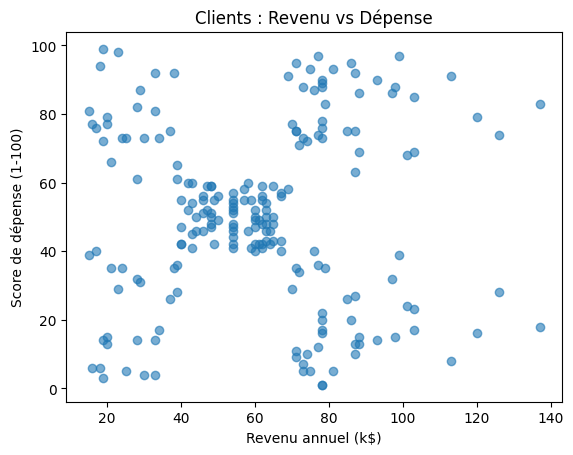

In [2]:
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], alpha=0.6)
plt.xlabel("Revenu annuel (k$)")
plt.ylabel("Score de dépense (1-100)")
plt.title("Clients : Revenu vs Dépense")
plt.show()

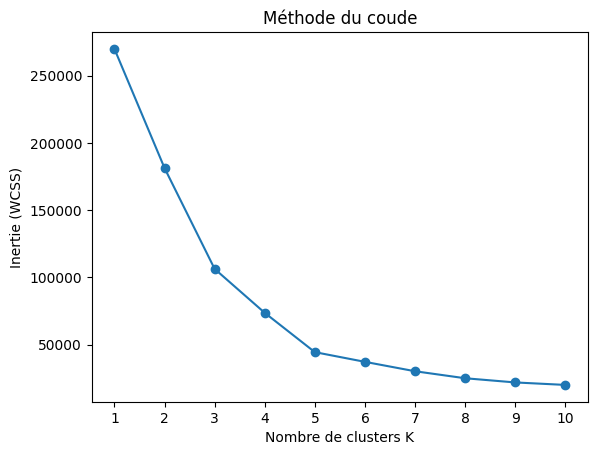

In [3]:
from sklearn.cluster import KMeans

X = df[["Annual Income (k$)", "Spending Score (1-100)"]].values

inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker="o")
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie (WCSS)")
plt.title("Méthode du coude")
plt.xticks(K_range)
plt.show()

In [4]:
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X)
    print(f"K = {k} -> silhouette = {silhouette_score(X, labels):.3f}")

K = 2 -> silhouette = 0.297
K = 3 -> silhouette = 0.468
K = 4 -> silhouette = 0.493
K = 5 -> silhouette = 0.554
K = 6 -> silhouette = 0.540
K = 7 -> silhouette = 0.529
K = 8 -> silhouette = 0.455
K = 9 -> silhouette = 0.456
K = 10 -> silhouette = 0.441


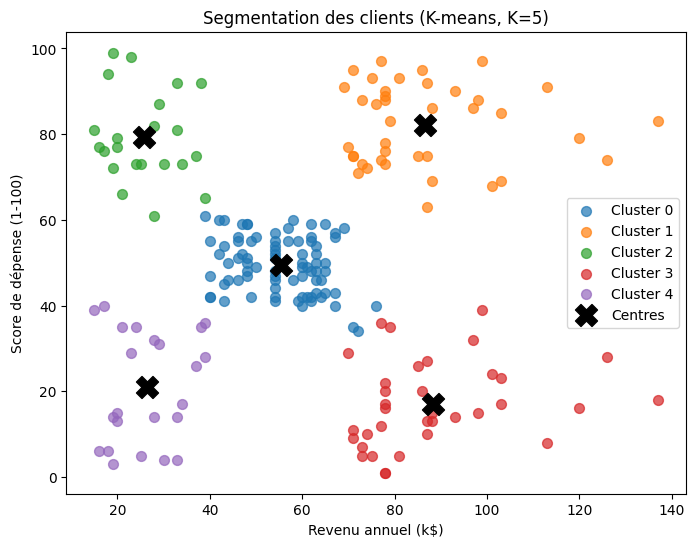

In [5]:
kmeans = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
for c in range(5):
    pts = df[df["Cluster"] == c]
    plt.scatter(pts["Annual Income (k$)"], pts["Spending Score (1-100)"],
                s=50, alpha=0.7, label=f"Cluster {c}")
plt.scatter(centers[:, 0], centers[:, 1], s=250, c="black", marker="X", label="Centres")
plt.xlabel("Revenu annuel (k$)")
plt.ylabel("Score de dépense (1-100)")
plt.title("Segmentation des clients (K-means, K=5)")
plt.legend()
plt.show()

In [6]:
def nommer(revenu, score):
    r = "Revenu élevé" if revenu > 70 else ("Revenu faible" if revenu < 40 else "Revenu moyen")
    s = "dépense beaucoup" if score > 60 else ("dépense peu" if score < 40 else "dépense moyennement")
    return f"{r}, {s}"

profil = df.groupby("Cluster").agg(
    Nb_clients=("CustomerID", "count"),
    Age_moyen=("Age", "mean"),
    Revenu_moyen=("Annual Income (k$)", "mean"),
    Score_moyen=("Spending Score (1-100)", "mean"),
).round(1)
profil["Profil"] = [nommer(r, s) for r, s in zip(profil["Revenu_moyen"], profil["Score_moyen"])]
profil

,Nb_clients,Age_moyen,Revenu_moyen,Score_moyen,Profil
Cluster,,,,,
0,81,42.7,55.3,49.5,"Revenu moyen, dépense moyennement"
1,39,32.7,86.5,82.1,"Revenu élevé, dépense beaucoup"
2,22,25.3,25.7,79.4,"Revenu faible, dépense beaucoup"
3,35,41.1,88.2,17.1,"Revenu élevé, dépense peu"
4,23,45.2,26.3,20.9,"Revenu faible, dépense peu"


In [7]:
df.to_csv("customers_clusters.csv", index=False)
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


## Conclusion
- Algorithme : **K-means** (non supervisé), variables : revenu annuel et score de dépense
- Choix de K = 5 grâce à la **méthode du coude** et au **score silhouette** (0.554, le meilleur)
- 5 segments identifiés :
  - VIP : revenu élevé, dépense élevée (39 clients)
  - Potentiel : revenu élevé, dépense faible (35 clients)
  - Standard : revenu et dépense moyens (81 clients)
  - Jeunes dépensiers : revenu faible, dépense élevée (22 clients)
  - Prudents : revenu faible, dépense faible (23 clients)
- Utilité : adapter les campagnes marketing à chaque segment.